# Enterprise Data Reconciliation & Analytics

This notebook implements the four-phase data reconciliation and analytics pipeline described in the project README.

### Phases
1. SQL Extraction
2. Regex & Unstructured Data Processing
3. Financial Reconciliation & Data Integration
4. Aggregation & Visualization

In [ ]:
# ===================================================================
# PHASE 1: SQL EXTRACTION
# ===================================================================
import sqlite3
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns


# Connecting to the database
conn = sqlite3.connect("enterprise_database (1).db")

# SQL query to get the latest Active record for each user
query = """
WITH latest_users AS (
    SELECT
        user_id,
        name,
        status,
        updated_at,
        ROW_NUMBER() OVER (
            PARTITION BY user_id
            ORDER BY updated_at DESC
        ) AS rn
    FROM users
)

SELECT
    user_id,
    name,
    status,
    updated_at
FROM latest_users
WHERE rn = 1
AND status = 'Active';
"""

# Load the result into a Pandas DataFrame
df_active_users = pd.read_sql_query(query, conn)

# Display the first 5 rows
df_active_users.head()


,user_id,name,status,updated_at
0,U-00001,User_U-00001,Active,2023-01-28 14:00:00
1,U-00003,User_U-00003,Active,2023-01-22 14:00:00
2,U-00005,User_U-00005,Active,2023-01-17 14:00:00
3,U-00006,User_U-00006,Active,2023-01-05 14:00:00
4,U-00007,User_U-00007,Active,2023-01-27 14:00:00


In [ ]:
# ===================================================================
# PHASE 2: REGEX & UNSTRUCTURED DATA WRANGLING
# ===================================================================

# Import required libraries
import re
import pandas as pd

# Read the server log file
with open("server_logs (1).txt", "r") as file:
    logs = file.readlines()

# Keep only successful INFO transactions
info_logs = [line for line in logs if "INFO" in line]

# Regex pattern to extract date, user ID, product ID, and EUR value
pattern = r'\[(.*?)\].*?""u"":""(.*?)"".*?""item_code"":""(.*?)"".*?""eur_val"":([\d.]+)'

# Store extracted transactions
transactions = []

# Extract information from each INFO log
for line in info_logs:
    match = re.search(pattern, line)

    if match:
        date, user_id, product_id, eur_value = match.groups()

        transactions.append({
            "date": date,
            "user_id": user_id,
            "product_id": product_id,
            "eur_value": float(eur_value)
        })

# Convert extracted data into a Pandas DataFrame
extracted_data = pd.DataFrame(transactions)

# Check the extraction
print("Total logs:", len(logs))
print("INFO logs:", len(info_logs))
print("Extracted transactions:", len(transactions))

# Display first 5 extracted records
print(extracted_data.head())

Total logs: 100001
INFO logs: 94902
Extracted transactions: 94902
                  date  user_id product_id  eur_value
0  2023-03-15 00:00:00  U-19484    PRD-874    3404.44
1  2023-05-09 00:00:00  U-18932    PRD-905    3406.21
2  2023-10-21 00:00:00  U-15882    PRD-284     164.08
3  2023-01-10 00:00:00  U-22781    PRD-665      26.80
4  2023-05-23 00:00:00  U-13348    PRD-589    4964.77


In [ ]:
# ===================================================================
# PHASE 3: FINANCIAL RECONCILIATION & MERGING
# ===================================================================

import pandas as pd

# LOAD DAILY EXCHANGE RATES
exchange_rates = pd.read_csv("daily_exchange_rates (1).csv")
print(exchange_rates.head())

# PREPARE THE DATE COLUMN
exchange_rates["Date"] = pd.to_datetime(exchange_rates["Date"])
exchange_rates = exchange_rates.sort_values("Date")

# CREATE COMPLETE DAILY DATE RANGE
all_dates = pd.date_range(
    start=exchange_rates["Date"].min(),
    end=exchange_rates["Date"].max(),
    freq="D"
)

# ADD MISSING WEEKEND DATES
exchange_rates = (
    exchange_rates
    .set_index("Date")
    .reindex(all_dates)
)
exchange_rates.index.name = "Date"
exchange_rates = exchange_rates.reset_index()

# FORWARD-FILL MISSING EXCHANGE RATES
exchange_rates["EUR_to_USD"] = (
    exchange_rates["EUR_to_USD"].ffill()
)
print(exchange_rates.head(10))

# PREPARE TRANSACTION DATES
extracted_data["date"] = pd.to_datetime(
    extracted_data["date"]
)
extracted_data["Date"] = (
    extracted_data["date"].dt.normalize()
)

# MERGE TRANSACTIONS WITH EXCHANGE RATES
df_reconciled = pd.merge(
    extracted_data,
    exchange_rates,
    on="Date",
    how="left"
)
print(df_reconciled.head())

# CALCULATE USD REVENUE
df_reconciled["USD_Revenue"] = (
    df_reconciled["eur_value"]
    * df_reconciled["EUR_to_USD"]
)
print(df_reconciled[[
    "user_id",
    "product_id",
    "eur_value",
    "EUR_to_USD",
    "USD_Revenue"
]].head())

# MERGE WITH ACTIVE USERS
df_final = pd.merge(
    df_reconciled,
    df_active_users,
    on="user_id",
    how="inner"
)

# CHECK FINAL DATASET
print(df_final.head())
print(df_final.columns)
print("Final Number of Records:", len(df_final))

# CHECK FOR MISSING VALUES
print(df_final.isnull().sum())

         Date  EUR_to_USD
0  2023-01-01    1.124836
1  2023-01-02    1.093087
2  2023-01-03    1.132384
3  2023-01-04    1.176151
4  2023-01-05    1.088292
        Date  EUR_to_USD
0 2023-01-01    1.124836
1 2023-01-02    1.093087
2 2023-01-03    1.132384
3 2023-01-04    1.176151
4 2023-01-05    1.088292
5 2023-01-06    1.088292
6 2023-01-07    1.088292
7 2023-01-08    1.138372
8 2023-01-09    1.076526
9 2023-01-10    1.127128
        date  user_id product_id  eur_value       Date  EUR_to_USD
0 2023-03-15  U-19484    PRD-874    3404.44 2023-03-15    1.178232
1 2023-05-09  U-18932    PRD-905    3406.21 2023-05-09    1.104983
2 2023-10-21  U-15882    PRD-284     164.08 2023-10-21    1.075350
3 2023-01-10  U-22781    PRD-665      26.80 2023-01-10    1.127128
4 2023-05-23  U-13348    PRD-589    4964.77 2023-05-23    1.019626
   user_id product_id  eur_value  EUR_to_USD  USD_Revenue
0  U-19484    PRD-874    3404.44    1.178232  4011.220772
1  U-18932    PRD-905    3406.21    1.104983  3763.

      Month   USD_Revenue
0   2023-01  1.284176e+07
1   2023-02  1.143613e+07
2   2023-03  1.234893e+07
3   2023-04  1.201538e+07
4   2023-05  1.233364e+07
5   2023-06  1.208436e+07
6   2023-07  1.244416e+07
7   2023-08  1.281273e+07
8   2023-09  1.222895e+07
9   2023-10  1.250133e+07
10  2023-11  1.258822e+07
11  2023-12  1.263902e+07


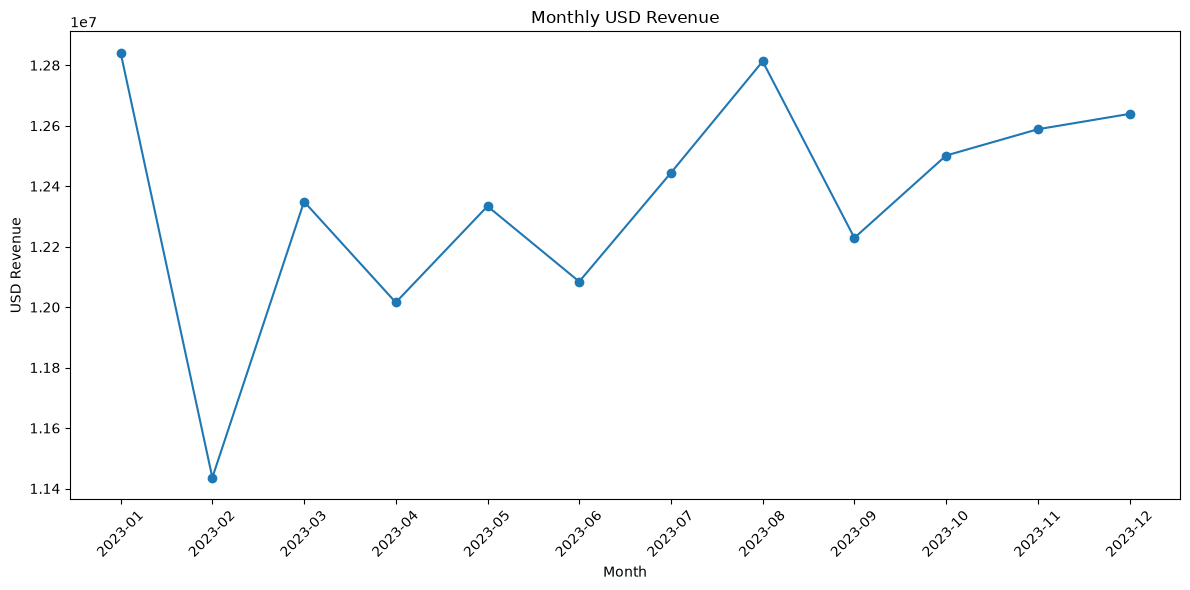

   user_id   USD_Revenue
0  U-06582  40050.988262
1  U-23313  39555.806629
2  U-03805  39529.945085
3  U-20018  38649.965242
4  U-06489  38629.142146


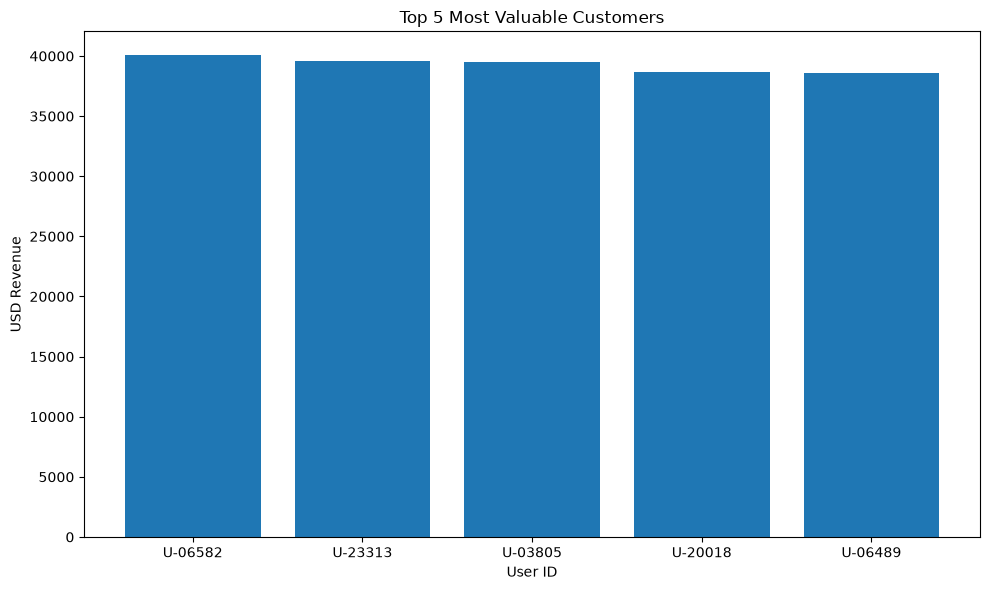

Final dataset saved successfully.
Top 5 Customers by USD Revenue:
user_id
U-06582    40050.988262
U-23313    39555.806629
U-03805    39529.945085
U-20018    38649.965242
U-06489    38629.142146
Name: USD_Revenue, dtype: float64


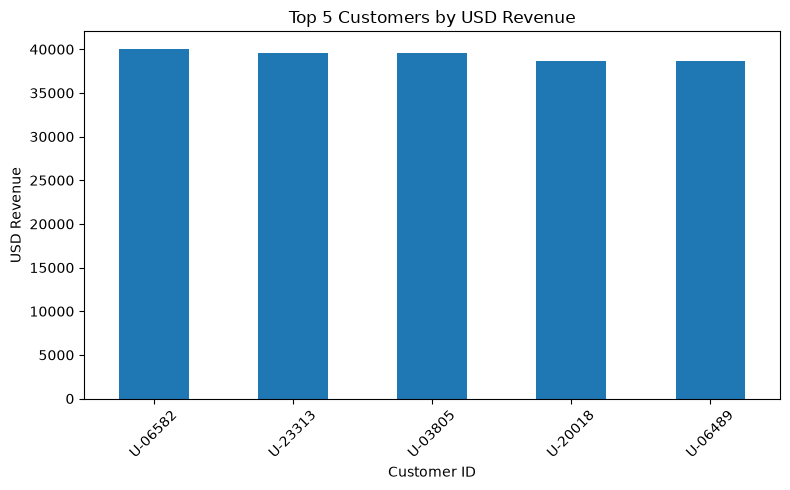

In [ ]:
# ===================================================================
# PHASE 4: AGGREGATION & VISUALIZATION (CFO DASHBOARD)
# ===================================================================

import pandas as pd
import matplotlib.pyplot as plt


# MONTHLY USD REVENUE

df_final["Month"] = df_final["date"].dt.to_period("M")

monthly_revenue = (
    df_final
    .groupby("Month")["USD_Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["Month"] = monthly_revenue["Month"].astype(str)

print(monthly_revenue)

# MONTHLY USD REVENUE CHART

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["USD_Revenue"],
    marker="o"
)

plt.title("Monthly USD Revenue")
plt.xlabel("Month")
plt.ylabel("USD Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# TOP 5 MOST VALUABLE CUSTOMERS

top_customers = (
    df_final
    .groupby("user_id")["USD_Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

print(top_customers)

# TOP 5 CUSTOMERS CHART

plt.figure(figsize=(10, 6))

plt.bar(
    top_customers["user_id"],
    top_customers["USD_Revenue"]
)

plt.title("Top 5 Most Valuable Customers")
plt.xlabel("User ID")
plt.ylabel("USD Revenue")

plt.tight_layout()
plt.show()

# SAVE FINAL DATASET

df_final.to_csv("final_reconciled_data.csv", index=False)

print("Final dataset saved successfully.")



# TOP 5 CUSTOMERS BAR CHART

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

top_5_customers.plot(kind="bar")

plt.title("Top 5 Customers by USD Revenue")
plt.xlabel("Customer ID")
plt.ylabel("USD Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

